In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [2]:
daily = pd.read_csv("../data/processed/daily_sales.csv")

daily.head()

,Date,TotalPrice,Rolling_7,Rolling_30
0,2009-12-01,43894.87,NaN,NaN
1,2009-12-02,52762.06,NaN,NaN
2,2009-12-03,67413.62,NaN,NaN
3,2009-12-04,33913.81,NaN,NaN
4,2009-12-05,9803.05,NaN,NaN


In [3]:
series = daily["TotalPrice"].values.reshape(-1,1)

series.shape

(374, 1)

In [4]:
scaler = MinMaxScaler()

scaled = scaler.fit_transform(series)

In [5]:
LOOKBACK = 30

X = []
y = []

for i in range(len(scaled)-LOOKBACK):
    X.append(scaled[i:i+LOOKBACK])
    y.append(scaled[i+LOOKBACK])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(344, 30, 1)
(344, 1)


In [6]:
split = int(len(X)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

In [7]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [8]:
class LSTMModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=64,
            num_layers=2,
            batch_first=True
        )

        self.fc = nn.Linear(64,1)

    def forward(self,x):

        output,_ = self.lstm(x)

        output = output[:,-1,:]

        return self.fc(output)

In [9]:
model = LSTMModel()

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [10]:
EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()

    optimizer.zero_grad()

    prediction = model(X_train)

    loss = criterion(prediction,y_train)

    loss.backward()

    optimizer.step()

    if epoch%10==0:

        print(epoch,loss.item())

0 0.08092720806598663
10 0.017858868464827538
20 0.014768659137189388
30 0.015232011675834656
40 0.014854960143566132


In [11]:
model.eval()

with torch.no_grad():

    pred = model(X_test).numpy()

In [12]:
pred = scaler.inverse_transform(pred)

actual = scaler.inverse_transform(
    y_test.numpy()
)

In [13]:
mae = mean_absolute_error(actual,pred)

rmse = np.sqrt(
    mean_squared_error(actual,pred)
)

mape = np.mean(
    np.abs((actual-pred)/actual)
)*100

print("MAE :",mae)
print("RMSE:",rmse)
print("MAPE:",mape)

MAE : 21414.248046875
RMSE: 24963.445915978828
MAPE: inf


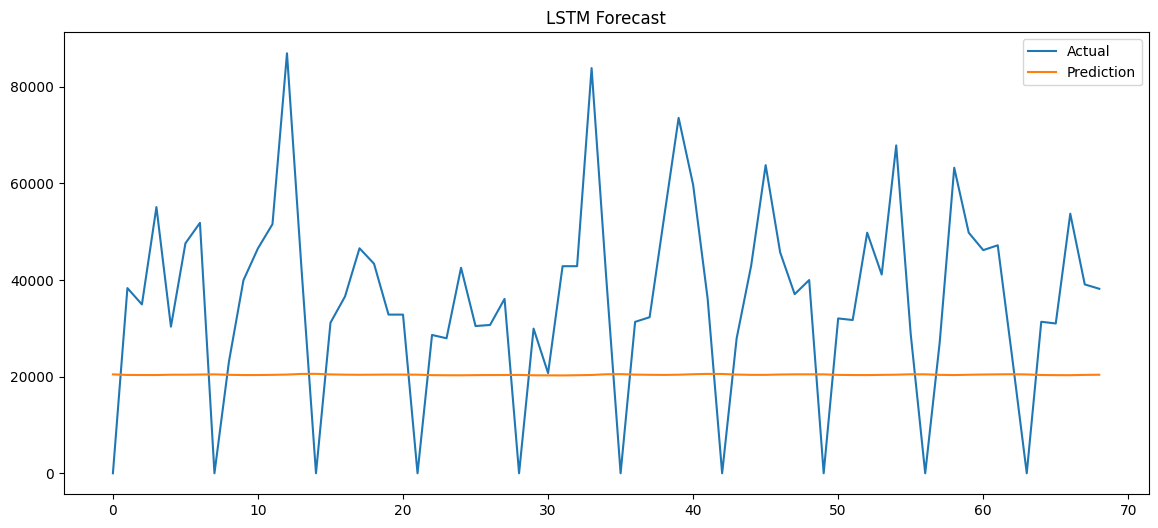

In [14]:
plt.figure(figsize=(14,6))

plt.plot(actual,label="Actual")

plt.plot(pred,label="Prediction")

plt.legend()

plt.title("LSTM Forecast")

plt.show()

In [15]:
torch.save(
    model.state_dict(),
    "../models/lstm_model.pth"
)

In [16]:
forecast = pd.DataFrame({

    "Actual":actual.flatten(),

    "Prediction":pred.flatten()

})

forecast.to_csv(

    "../data/processed/forecast_lstm.csv",

    index=False
)